### Extract features and justify the methods used

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from cycler import cycler

plt.rcParams.update({
    'figure.figsize': [10.0, 6.0],
    'xtick.labelsize': 12.0,
    'ytick.labelsize': 12.0,
    'axes.labelsize': 12.0,
    'font.size': 14.0,
    'legend.labelcolor': '#000000',
    'xtick.labelcolor': '#000000',
    'ytick.labelcolor': '#000000',
    'axes.labelcolor': '#000000',
    'axes.titlecolor': '#000000',
    'axes.edgecolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'text.color': '#000000',
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.prop_cycle': cycler(color=['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3', '#b2df8a', '#fb9a99']),
})

In [3]:
df = pd.read_csv('cyberbullying_datasets/course_dataset/clean_cb.csv')
df = df.drop("Text", axis=1)
print(df.shape)
df.head()

(11100, 2)


,CB_Label,clean_text
0,0,damn someone nana beach not think ic steal qui...
1,0,kidding ! dick clark corpse mechanically opera...
2,0,read article jobros think damn cash jobro poke...
3,0,get fucking day sprinkle sunshine douchebaggery
4,0,listen elliott smith fucking hate kanye west v...


In [4]:
# Remove missing values
print(df.isna().sum(), '\n')
df.dropna(inplace=True)
print(df.isna().sum())

# Reset the index after removal of missing values
df = df.reset_index().drop(['index'], axis=1, inplace=False)
df

CB_Label       0
clean_text    31
dtype: int64 

CB_Label      0
clean_text    0
dtype: int64


,CB_Label,clean_text
0,0,damn someone nana beach not think ic steal qui...
1,0,kidding ! dick clark corpse mechanically opera...
2,0,read article jobros think damn cash jobro poke...
3,0,get fucking day sprinkle sunshine douchebaggery
4,0,listen elliott smith fucking hate kanye west v...
...,...,...
11064,1,worry little head wipe ass hula hoop
11065,1,ya dumb fuck strategic move ! ! get blacklist ...
11066,1,lana shit eye brown xanno green xalike emerald...
11067,1,ai lie let USER disqusxaxa nigga tell mothafuc...


### TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    # max_features=5000,
    ngram_range=(1,2),
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

#### Sjekker topp unigrams og bigrams som forekommer for hver klassifikasjon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# top unigrams
for label in sorted(df['CB_Label'].unique()):
    texts = df[df['CB_Label'] == label]['clean_text']
    
    # Lær og transformer teksten i denne klassen
    X_label = tfidf.fit_transform(texts)
    
    # Hent feature names og summer TF-IDF verdier
    feature_names = tfidf.get_feature_names_out()
    tfidf_sum = np.array(X_label.sum(axis=0)).flatten()
    
    # Lag dataframe
    tfidf_df = pd.DataFrame({'term': feature_names, 'tfidf': tfidf_sum})
    tfidf_df = pd.concat([df[['CB_Label']].reset_index(drop=True), tfidf_df], axis=1)
    top20 = tfidf_df.sort_values(by='tfidf', ascending=False).head(20)
    
    # --- Plot topp 20 unigrams ---
    plt.figure(figsize=(10,5))
    plt.barh(top20['term'][::-1], top20['tfidf'][::-1], color='royalblue' if label==0 else 'tomato')
    plt.title(f'Top 20 unigrams for CB_Label = {label} ({ "Non-bullying" if label==0 else "Cyberbullying" })')
    plt.xlabel('TF-IDF score')
    plt.tight_layout()
    plt.show()

In [ ]:
# Top bigrams
for label in sorted(df['CB_Label'].unique()):
    texts = df[df['CB_Label'] == label]['clean_text']
    
    # Lær og transformer teksten i denne klassen
    X_label = tfidf.fit_transform(texts)
    
    # Hent feature names og summer TF-IDF verdier
    feature_names = tfidf.get_feature_names_out()
    tfidf_sum = np.array(X_label.sum(axis=0)).flatten()
    
    # Lag dataframe
    tfidf_df = pd.DataFrame({'term': feature_names, 'tfidf': tfidf_sum})
    tfidf_df = pd.concat([df[['CB_Label']].reset_index(drop=True), tfidf_df], axis=1)

    #Topp 20 bigrams
    bigrams_df = tfidf_df[tfidf_df['term'].str.contains(' ')]
    top20_bigrams = bigrams_df.sort_values(by='tfidf', ascending=False).head(20)

    
    plt.figure(figsize=(10,5))
    plt.barh(top20_bigrams['term'][::-1], top20['tfidf'][::-1], color='royalblue' if label==0 else 'tomato')
    plt.title(f'Top 20 bigrams for CB_Label = {label} ({ "Non-bullying" if label==0 else "Cyberbullying" })')
    plt.xlabel('TF-IDF score')
    plt.tight_layout()
    plt.show()

##### Legger det i en CSV fil slik at vi kan jobbe med det!

Kjør først for enkeltord, og deretter bytt om (1,1) med (2,2) for bigrams!

In [5]:
# --- TF-IDF vectorization ---
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2), # both uni- and bigrams
    # ngram_range=(2, 2), # only bigrams (don't specify ngram_range to only get unigrams)
)

# Tren TF-IDF på alle tekstene
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Hent feature (ord/bigrams)
feature_names = tfidf.get_feature_names_out()

# Konverter til DataFrame
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)

# Sjekk resultatet
print(X_tfidf_df.shape)
X_tfidf_df.head()

(11069, 2000)


,ability,able,absolutely,abuse,accept,accident,account,accuse,act,act like,...,youtube,youu,yr,yrs,yuck,yuh,yup,yur,yuu,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
pd.concat([X_tfidf_df[['hate', 'love', 'damn', 'fuck']].head(), df['CB_Label'].head()], axis=1)

,hate,love,damn,fuck,CB_Label
0,0.000000,0.0,0.148853,0.0,0
1,0.000000,0.0,0.000000,0.0,0
2,0.000000,0.0,0.163305,0.0,0
3,0.000000,0.0,0.000000,0.0,0
4,0.126349,0.0,0.000000,0.0,0


In [6]:
tfidf_pca_full = PCA(n_components=min(*X_tfidf_df.shape), random_state=0).fit(X_tfidf_df)

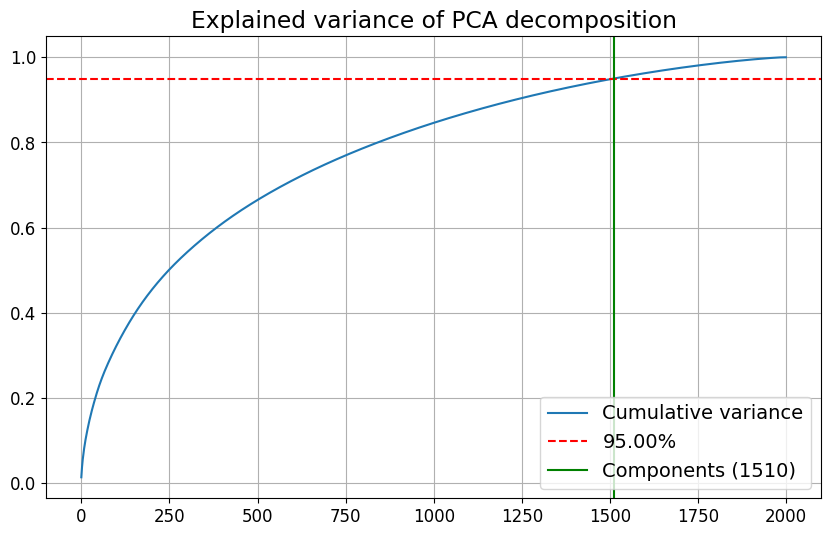

In [7]:
optimal_variance_percentage = .95

cumulative_variance_ratio = np.cumsum(tfidf_pca_full.explained_variance_ratio_)
optimal_component_count = np.argmax(cumulative_variance_ratio>=optimal_variance_percentage)


fig, ax = plt.subplots(1, 1)

ax.plot(cumulative_variance_ratio, label=f'Cumulative variance')
ax.axhline(optimal_variance_percentage, color='red', linestyle='--', label=f'{optimal_variance_percentage * 100:.2f}%')
ax.axvline(optimal_component_count, color='green', label=f'Components ({optimal_component_count})')

ax.set_title('Explained variance of PCA decomposition')
ax.legend(loc='lower right')
ax.grid(True)

plt.show()

In [8]:
data_compressed = PCA(n_components=optimal_component_count, random_state=0).fit_transform(X_tfidf_df)
data_compressed = pd.DataFrame(data_compressed)
data_compressed['bullying'] = df['CB_Label']
data_compressed.head()

,0,1,2,3,4,5,6,7,8,9,...,1501,1502,1503,1504,1505,1506,1507,1508,1509,bullying
0,-0.002080,-0.098498,0.138242,0.045598,-0.017458,-0.010139,-0.003090,-0.014100,-0.046547,-0.057953,...,-0.002891,0.003126,-0.012274,0.004546,0.007370,-0.007921,-0.005182,0.000307,0.003477,0
1,-0.001004,-0.026420,-0.033260,-0.020460,-0.026516,-0.016710,-0.015870,-0.011796,-0.033633,0.017747,...,-0.004328,-0.002586,0.003775,0.007126,0.010125,0.002154,0.006175,-0.002659,-0.005006,0
2,-0.001233,-0.106335,0.143678,0.047725,-0.027387,-0.019054,-0.010861,-0.015677,-0.063882,-0.048646,...,-0.004825,0.014586,0.002918,0.013004,0.009871,-0.004770,-0.011197,0.017138,-0.009652,0
3,0.005458,-0.020394,-0.020959,-0.058454,-0.043223,-0.066322,-0.014348,-0.058030,-0.097849,0.384076,...,-0.000391,-0.002202,-0.000409,0.002862,-0.003368,-0.001770,0.002416,0.002867,-0.001941,0
4,-0.132864,0.120129,0.008963,-0.003725,-0.029059,-0.038662,-0.020293,-0.026932,-0.035289,0.191701,...,-0.016238,0.002461,0.011779,-0.018074,0.008246,-0.005105,0.010305,-0.008957,0.005785,0


In [9]:
data_compressed.to_csv('cyberbullying_datasets/course_dataset/cb_pca_compressed.csv.gz', index=False, compression='gzip')

In [18]:
X_train, X_test, y_train, y_test = train_test_split(data_compressed.drop(['bullying'], axis=1), data_compressed['bullying'], 
                                                    test_size=0.3,
                                                    random_state=0)


test_model = LogisticRegression().fit(X_train, y_train)
test_model.score(X_test, y_test)

0.711231556760012

In [19]:
# 100% of the columns

X_tr, X_ts, y_tr, y_ts = train_test_split(X_tfidf_df, df['CB_Label'],
                                          test_size=0.3,
                                          random_state=0)


text_model_2 = LogisticRegression().fit(X_tr, y_tr)
text_model_2.score(X_ts, y_ts)

0.717554953327311